# Explore Synthetic 5G Receiver Data

This notebook helps inspect the current synthetic dataset from `src/data/dataset.py`.

It focuses on:
- sample shapes and tensor layout
- received signal vs. LS channel estimate
- channel magnitude/phase structure across the OFDM grid
- simple constellation-style views
- batch-level dataset statistics
- a quick forward pass through the dense baseline

> Note: this notebook uses the current PyTorch synthetic generator, not the future Sionna pipeline yet.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / 'src').exists():
    raise RuntimeError('Run this notebook from the repository root or inside notebooks/.')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

project_root

PosixPath('/Users/ramsay/school/knn/project')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from src.data.dataset import NeuralReceiverDataset
from src.models.dense import StaticDenseNRX

plt.style.use('ggplot')
torch.set_printoptions(precision=4, sci_mode=False)

In [3]:
dataset = NeuralReceiverDataset(
    num_samples=64,
    num_subcarriers=128,
    num_ofdm_symbols=14,
    bits_per_symbol=4,
    num_rx_antennas=4,
    snr_db_range=(0.0, 24.0),
    channel_estimator_noise_std=0.15,
    channel_variation=0.25,
    seed=67,
)

sample_idx = 0
features, target_bits, channel_target = dataset[sample_idx]

print('features shape      :', tuple(features.shape))
print('target bits shape   :', tuple(target_bits.shape))
print('channel target shape:', tuple(channel_target.shape))

features shape      : (16, 128, 14)
target bits shape   : (7168,)
channel target shape: (8, 128, 14)


In [4]:
def split_feature_tensor(features, channel_target, num_rx_antennas=4):
    rx_real = features[:num_rx_antennas]
    rx_imag = features[num_rx_antennas : 2 * num_rx_antennas]
    ls_real = features[2 * num_rx_antennas : 3 * num_rx_antennas]
    ls_imag = features[3 * num_rx_antennas : 4 * num_rx_antennas]

    received = torch.complex(rx_real, rx_imag)
    ls_estimate = torch.complex(ls_real, ls_imag)
    channel = torch.complex(channel_target[:num_rx_antennas], channel_target[num_rx_antennas:])
    bit_grid = target_bits.view(4, 128, 14)
    return received, ls_estimate, channel, bit_grid


def show_grid(ax, grid, title, cmap='viridis', colorbar=True):
    im = ax.imshow(grid.T, origin='lower', aspect='auto', cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel('Subcarrier')
    ax.set_ylabel('OFDM symbol')
    if colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def bits_to_qam16(bit_grid):
    bit_grid = bit_grid.permute(1, 2, 0).to(dtype=torch.int64)
    gray_levels = torch.tensor([-3.0, -1.0, 3.0, 1.0], dtype=torch.float32)
    i_idx = bit_grid[..., 0] * 2 + bit_grid[..., 1]
    q_idx = bit_grid[..., 2] * 2 + bit_grid[..., 3]
    i = gray_levels[i_idx]
    q = gray_levels[q_idx]
    return torch.complex(i, q) / np.sqrt(10.0)


received, ls_estimate, channel, bit_grid = split_feature_tensor(features, channel_target)
tx_symbols = bits_to_qam16(bit_grid)

print('received      :', tuple(received.shape))
print('ls_estimate   :', tuple(ls_estimate.shape))
print('channel       :', tuple(channel.shape))
print('bit_grid      :', tuple(bit_grid.shape))
print('tx_symbols    :', tuple(tx_symbols.shape))

received      : (4, 128, 14)
ls_estimate   : (4, 128, 14)
channel       : (4, 128, 14)
bit_grid      : (4, 128, 14)
tx_symbols    : (128, 14)


In [5]:
print('Bit mean           :', float(target_bits.mean()))
print('Received mean/std  :', float(features[:8].mean()), float(features[:8].std()))
print('LS estimate mean/std:', float(features[8:].mean()), float(features[8:].std()))
print('Channel |h| mean   :', float(channel.abs().mean()))
print('Channel |h| std    :', float(channel.abs().std()))
print('First 24 bits      :', target_bits[:24].to(dtype=torch.int64).tolist())

Bit mean           : 0.4977678656578064
Received mean/std  : -0.0018621206982061267 0.7848443984985352
LS estimate mean/std: -0.11607589572668076 0.7324274182319641
Channel |h| mean   : 0.8885077238082886
Channel |h| std    : 0.458893746137619
First 24 bits      : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0]


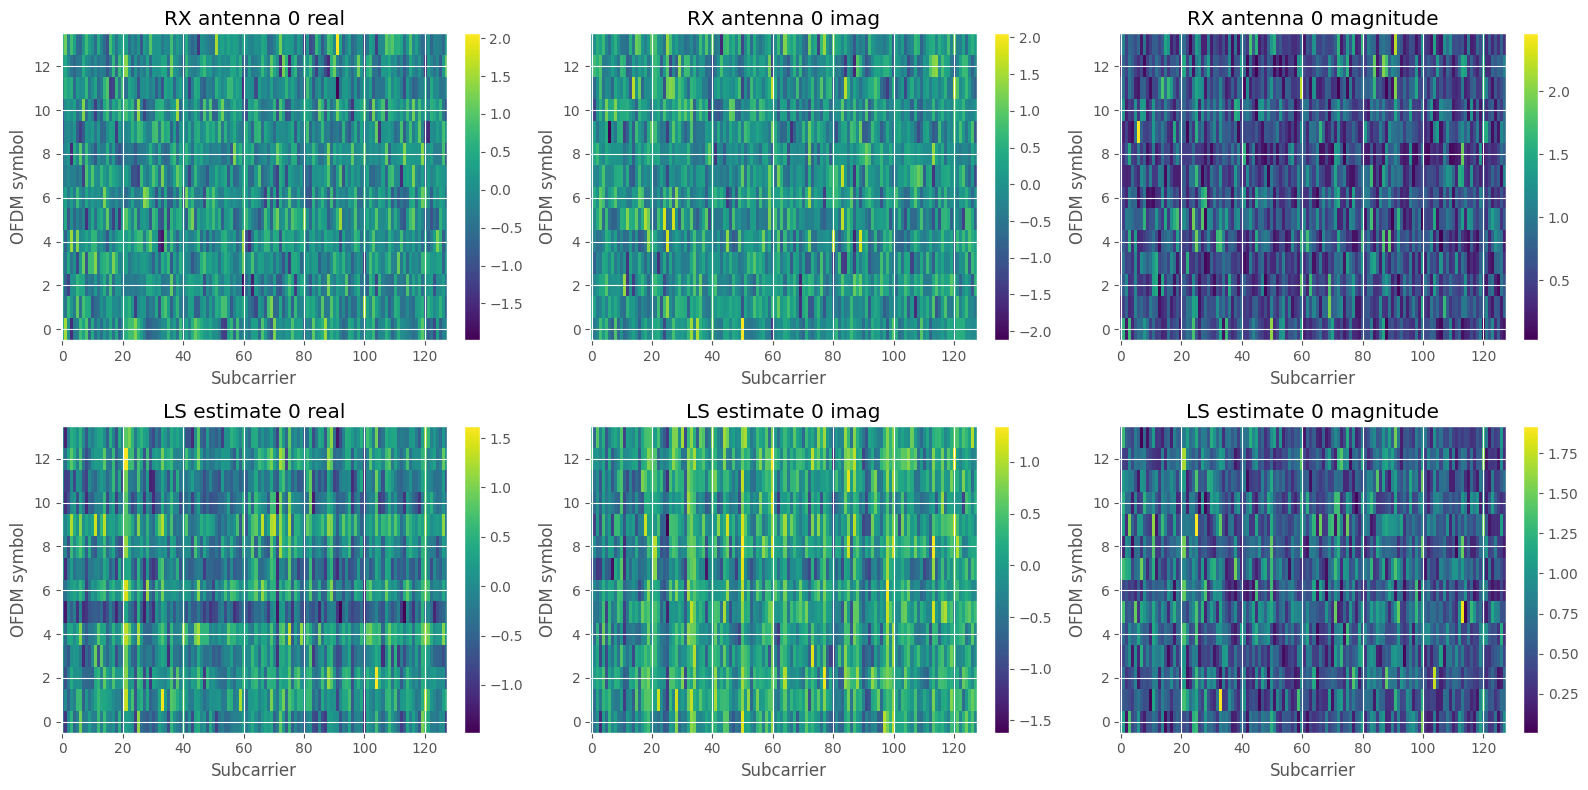

In [6]:
antenna = 0
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
show_grid(axes[0, 0], received[antenna].real, f'RX antenna {antenna} real')
show_grid(axes[0, 1], received[antenna].imag, f'RX antenna {antenna} imag')
show_grid(axes[0, 2], received[antenna].abs(), f'RX antenna {antenna} magnitude')
show_grid(axes[1, 0], ls_estimate[antenna].real, f'LS estimate {antenna} real')
show_grid(axes[1, 1], ls_estimate[antenna].imag, f'LS estimate {antenna} imag')
show_grid(axes[1, 2], ls_estimate[antenna].abs(), f'LS estimate {antenna} magnitude')
plt.tight_layout()

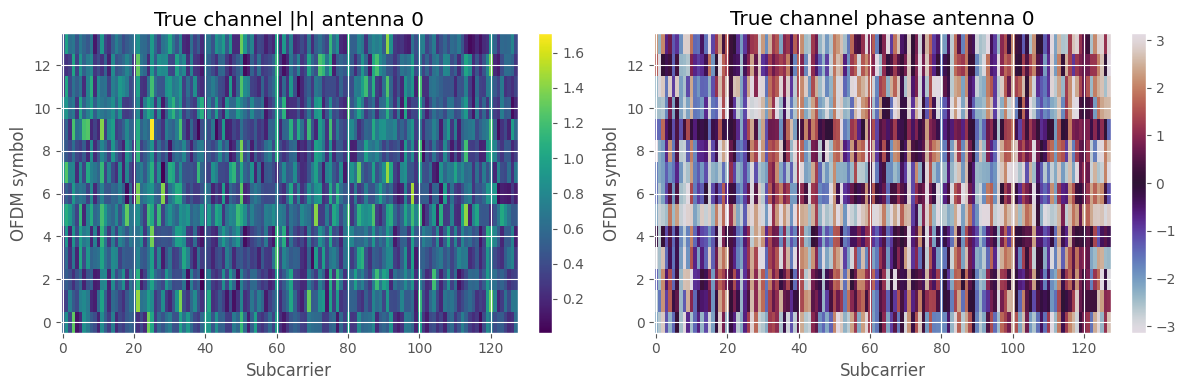

In [7]:
antenna = 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show_grid(axes[0], channel[antenna].abs(), f'True channel |h| antenna {antenna}')
show_grid(axes[1], torch.angle(channel[antenna]), f'True channel phase antenna {antenna}', cmap='twilight')
plt.tight_layout()

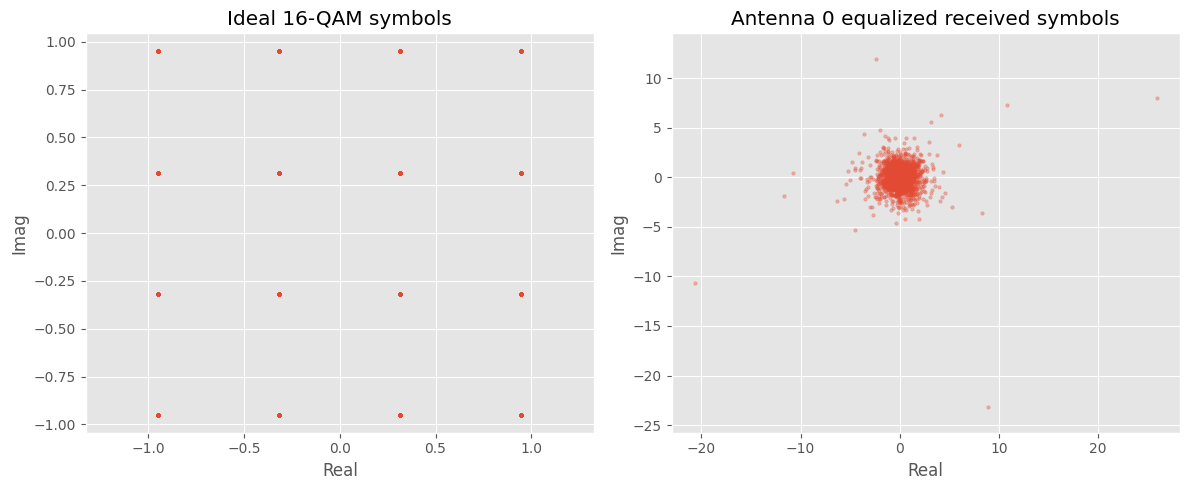

In [8]:
channel_safe = channel[0].clone()
channel_safe[channel_safe.abs() < 1e-6] = torch.tensor(1e-6 + 0j, dtype=channel_safe.dtype)
equalized = received[0] / channel_safe

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(tx_symbols.real.flatten(), tx_symbols.imag.flatten(), s=6, alpha=0.5)
axes[0].set_title('Ideal 16-QAM symbols')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Imag')
axes[0].axis('equal')

axes[1].scatter(equalized.real.flatten().cpu(), equalized.imag.flatten().cpu(), s=6, alpha=0.35)
axes[1].set_title('Antenna 0 equalized received symbols')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Imag')
axes[1].axis('equal')

plt.tight_layout()

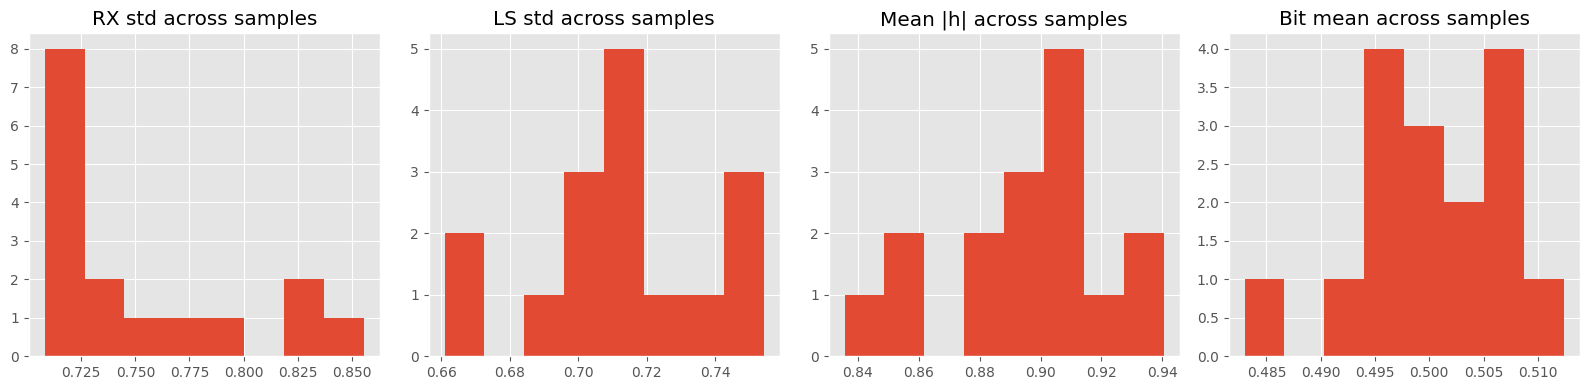

In [9]:
num_preview = 16
rx_std = []
ls_std = []
channel_abs_mean = []
bit_mean = []

for idx in range(num_preview):
    features_i, target_bits_i, channel_target_i = dataset[idx]
    rx_std.append(float(features_i[:8].std()))
    ls_std.append(float(features_i[8:].std()))
    channel_i = torch.complex(channel_target_i[:4], channel_target_i[4:])
    channel_abs_mean.append(float(channel_i.abs().mean()))
    bit_mean.append(float(target_bits_i.mean()))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].hist(rx_std, bins=8)
axes[0].set_title('RX std across samples')
axes[1].hist(ls_std, bins=8)
axes[1].set_title('LS std across samples')
axes[2].hist(channel_abs_mean, bins=8)
axes[2].set_title('Mean |h| across samples')
axes[3].hist(bit_mean, bins=8)
axes[3].set_title('Bit mean across samples')
plt.tight_layout()

In [10]:
model = StaticDenseNRX()
model.eval()

batch = torch.stack([dataset[i][0] for i in range(4)])
with torch.no_grad():
    outputs = model(batch)

print('batch shape           :', tuple(batch.shape))
print('logits shape          :', tuple(outputs['logits'].shape))
print('channel estimate shape:', tuple(outputs['channel_estimate'].shape))
print('logits mean/std       :', float(outputs['logits'].mean()), float(outputs['logits'].std()))

batch shape           : (4, 16, 128, 14)
logits shape          : (4, 7168)
channel estimate shape: (4, 8, 128, 14)
logits mean/std       : -0.05283922702074051 0.051602642983198166


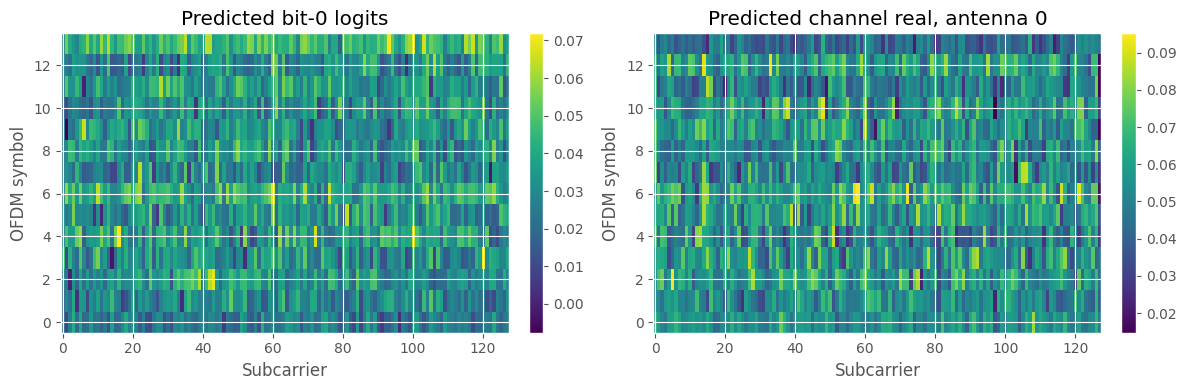

In [11]:
logit_grid = outputs['logits'][0].view(4, 128, 14)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show_grid(axes[0], logit_grid[0], 'Predicted bit-0 logits')
show_grid(axes[1], outputs['channel_estimate'][0, 0], 'Predicted channel real, antenna 0')
plt.tight_layout()

## Next ideas

Good follow-ups once the Sionna pipeline is ready:
- compare synthetic PyTorch samples against Sionna-generated samples
- add SNR-conditioned plots and per-SNR BLER estimates
- inspect pilot masks directly from the real 5G resource grid
- visualize dense vs. MoE routing behavior on the same sample